In [24]:
import kagglehub
import shutil, os

path = kagglehub.dataset_download('vetrirah/customer')
print('Downloaded to:', path)
print('Files available:')
for f in os.listdir(path):
    print(' -', f)

Downloaded to: C:\Users\Mok\.cache\kagglehub\datasets\vetrirah\customer\versions\1
Files available:
 - sample_submission.csv
 - Test.csv
 - Train.csv


In [25]:
# Copy Train.csv into our data folder
os.makedirs('data', exist_ok=True)
shutil.copy(os.path.join(path, 'Train.csv'), 'data/customers.csv')
print('Saved to data/customers.csv')

Saved to data/customers.csv


In [4]:
print('=== Column Info ===')
df.info()


=== Column Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print('Libraries loaded!')

Libraries loaded!


In [6]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))


=== Missing Values ===
                 Missing Count  Missing %
ID                           0       0.00
Gender                       0       0.00
Ever_Married               140       1.74
Age                          0       0.00
Graduated                   78       0.97
Profession                 124       1.54
Work_Experience            829      10.28
Spending_Score               0       0.00
Family_Size                335       4.15
Var_1                       76       0.94
Segmentation                 0       0.00


In [27]:
df = pd.read_csv('data/customers.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (8068, 11)


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
5,461319,Male,Yes,56,No,Artist,0.0,Average,2.0,Cat_6,C
6,460156,Male,No,32,Yes,Healthcare,1.0,Low,3.0,Cat_6,C
7,464347,Female,No,33,Yes,Healthcare,1.0,Low,3.0,Cat_6,D
8,465015,Female,Yes,61,Yes,Engineer,0.0,Low,3.0,Cat_7,D
9,465176,Female,Yes,55,Yes,Artist,1.0,Average,4.0,Cat_6,C


In [28]:
print('=== Column Info ===')
df.info()

=== Column Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [29]:
print('=== Summary Statistics ===')
df.describe(include='all')

=== Summary Statistics ===


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
count,8068.000000,8068,7928,8068.000000,7990,7944,7239.000000,8068,7733.000000,7992,8068
unique,NaN,2,2,NaN,2,9,NaN,3,NaN,7,4
top,NaN,Male,Yes,NaN,Yes,Artist,NaN,Low,NaN,Cat_6,D
freq,NaN,4417,4643,NaN,4968,2516,NaN,4878,NaN,5238,2268
mean,463479.214551,NaN,NaN,43.466906,NaN,NaN,2.641663,NaN,2.850123,NaN,NaN
std,2595.381232,NaN,NaN,16.711696,NaN,NaN,3.406763,NaN,1.531413,NaN,NaN
min,458982.000000,NaN,NaN,18.000000,NaN,NaN,0.000000,NaN,1.000000,NaN,NaN
25%,461240.750000,NaN,NaN,30.000000,NaN,NaN,0.000000,NaN,2.000000,NaN,NaN
50%,463472.500000,NaN,NaN,40.000000,NaN,NaN,1.000000,NaN,3.000000,NaN,NaN
75%,465744.250000,NaN,NaN,53.000000,NaN,NaN,4.000000,NaN,4.000000,NaN,NaN


In [30]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))

=== Missing Values ===
                 Missing Count  Missing %
ID                           0       0.00
Gender                       0       0.00
Ever_Married               140       1.74
Age                          0       0.00
Graduated                   78       0.97
Profession                 124       1.54
Work_Experience            829      10.28
Spending_Score               0       0.00
Family_Size                335       4.15
Var_1                       76       0.94
Segmentation                 0       0.00


In [31]:
print('=== Unique values per column ===')
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique — {list(df[col].unique()[:6])}')

=== Unique values per column ===
ID: 8068 unique — [np.int64(462809), np.int64(462643), np.int64(466315), np.int64(461735), np.int64(462669), np.int64(461319)]
Gender: 2 unique — ['Male', 'Female']
Ever_Married: 2 unique — ['No', 'Yes', nan]
Age: 67 unique — [np.int64(22), np.int64(38), np.int64(67), np.int64(40), np.int64(56), np.int64(32)]
Graduated: 2 unique — ['No', 'Yes', nan]
Profession: 9 unique — ['Healthcare', 'Engineer', 'Lawyer', 'Entertainment', 'Artist', 'Executive']
Work_Experience: 15 unique — [np.float64(1.0), np.float64(nan), np.float64(0.0), np.float64(4.0), np.float64(9.0), np.float64(12.0)]
Spending_Score: 3 unique — ['Low', 'Average', 'High']
Family_Size: 9 unique — [np.float64(4.0), np.float64(3.0), np.float64(1.0), np.float64(2.0), np.float64(6.0), np.float64(nan)]
Var_1: 7 unique — ['Cat_4', 'Cat_6', 'Cat_7', 'Cat_3', 'Cat_1', 'Cat_2']
Segmentation: 4 unique — ['D', 'A', 'B', 'C']


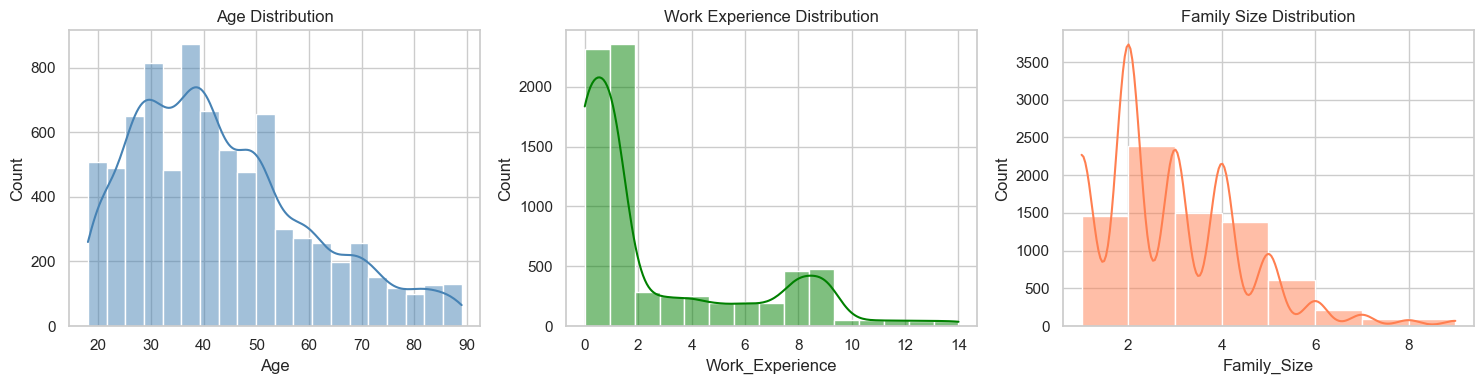

In [32]:
# Distribution of numerical columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['Age'].dropna(), bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Work_Experience'].dropna(), bins=15, kde=True, ax=axes[1], color='green')
axes[1].set_title('Work Experience Distribution')

sns.histplot(df['Family_Size'].dropna(), bins=8, kde=True, ax=axes[2], color='coral')
axes[2].set_title('Family Size Distribution')

plt.tight_layout()
plt.savefig('data/eda_numerical.png', dpi=150, bbox_inches='tight')
plt.show()

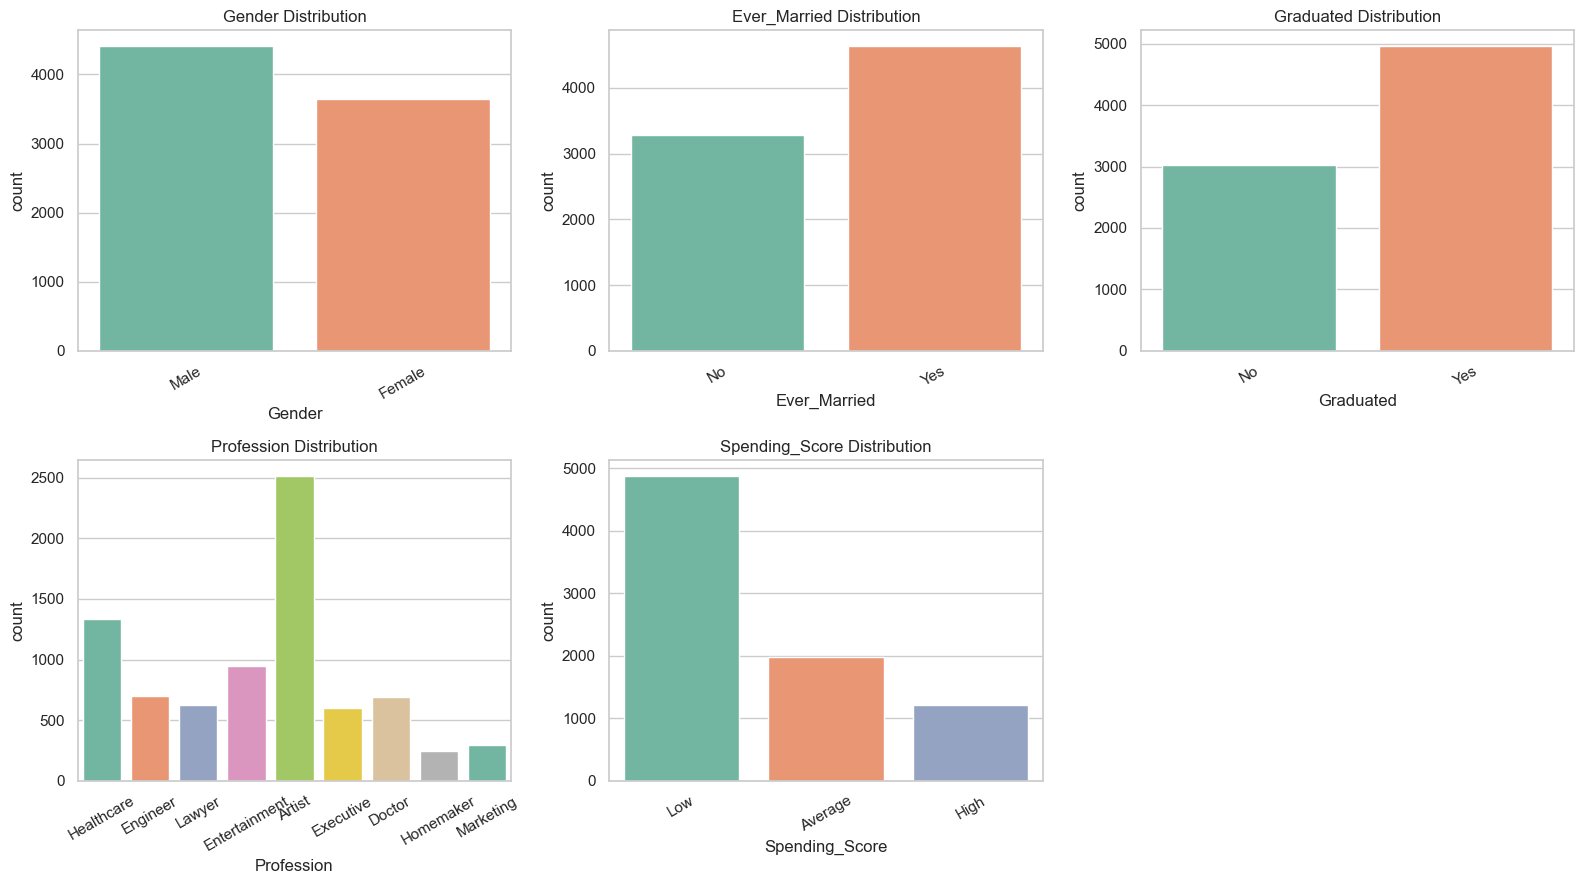

In [33]:
# Distribution of categorical columns
cat_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} Distribution')
    axes[i].tick_params(axis='x', rotation=30)

axes[5].set_visible(False)
plt.tight_layout()
plt.savefig('data/eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

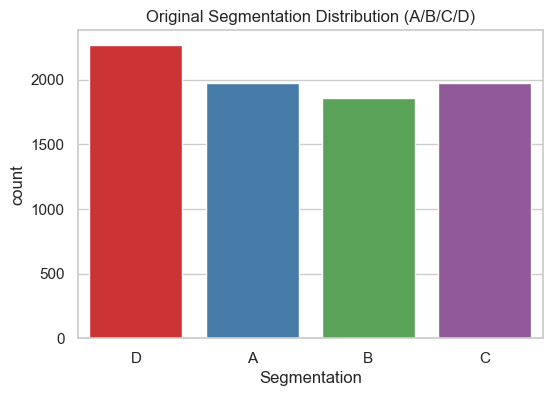

Segmentation
D    2268
A    1972
C    1970
B    1858
Name: count, dtype: int64


In [34]:
# Segmentation distribution (original labels — reference only)
plt.figure(figsize=(6, 4))
sns.countplot(x='Segmentation', data=df, palette='Set1')
plt.title('Original Segmentation Distribution (A/B/C/D)')
plt.savefig('data/eda_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print(df['Segmentation'].value_counts())

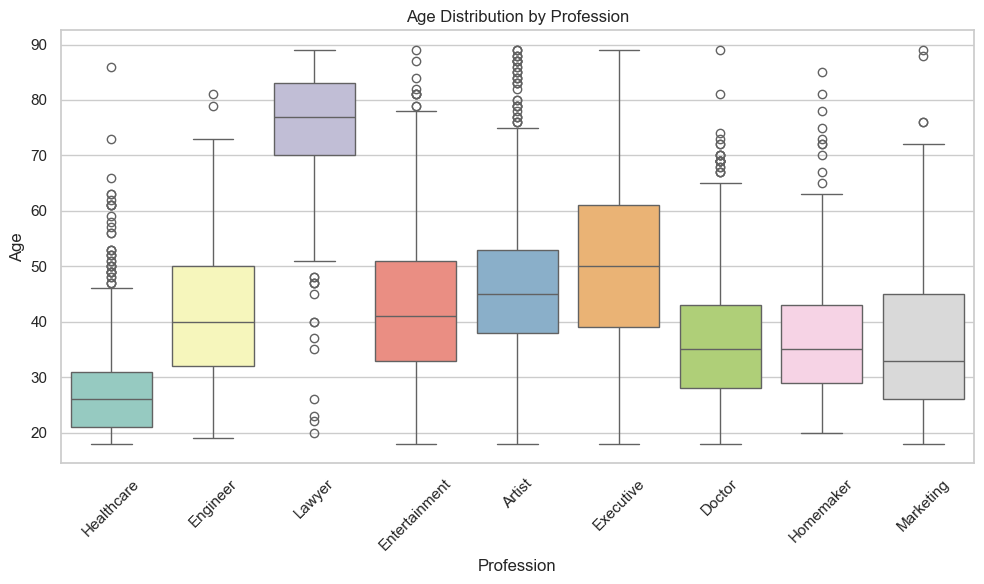

In [35]:
# Age distribution by Profession
plt.figure(figsize=(10, 6))
sns.boxplot(x='Profession', y='Age', data=df, palette='Set3')
plt.title('Age Distribution by Profession')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('data/eda_age_profession.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
df_clean = df.copy()

# Drop ID (not useful) and Segmentation (the label — removed for unsupervised learning)
df_clean = df_clean.drop(columns=['ID', 'Segmentation'])

print('Columns after dropping ID and Segmentation:')
print(list(df_clean.columns))

Columns after dropping ID and Segmentation:
['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1']


In [37]:
# Handle missing values
print('Missing values BEFORE:')
print(df_clean.isnull().sum())

# Numerical: fill with median
df_clean['Work_Experience'] = df_clean['Work_Experience'].fillna(df_clean['Work_Experience'].median())
df_clean['Family_Size']     = df_clean['Family_Size'].fillna(df_clean['Family_Size'].median())

# Categorical: fill with mode (most common value)
for col in ['Ever_Married', 'Graduated', 'Profession', 'Var_1']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print('\nMissing values AFTER:')
print(df_clean.isnull().sum())
print('\n✅ All missing values handled!')

Missing values BEFORE:
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
dtype: int64

Missing values AFTER:
Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
dtype: int64

✅ All missing values handled!


In [38]:
# Encode categorical columns to numbers
# Binary columns — simple 0/1
df_clean['Gender']       = df_clean['Gender'].map({'Male': 0, 'Female': 1})
df_clean['Ever_Married'] = df_clean['Ever_Married'].map({'No': 0, 'Yes': 1})
df_clean['Graduated']    = df_clean['Graduated'].map({'No': 0, 'Yes': 1})

# Ordinal column (Low < Average < High)
df_clean['Spending_Score'] = df_clean['Spending_Score'].map({'Low': 0, 'Average': 1, 'High': 2})

# Multi-category columns — LabelEncoder
le = LabelEncoder()
df_clean['Profession'] = le.fit_transform(df_clean['Profession'])
df_clean['Var_1']      = le.fit_transform(df_clean['Var_1'])

print('After encoding:')
print(df_clean.dtypes)
df_clean.head()

After encoding:
Gender               int64
Ever_Married         int64
Age                  int64
Graduated            int64
Profession           int64
Work_Experience    float64
Spending_Score       int64
Family_Size        float64
Var_1                int64
dtype: object


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,0,0,22,0,5,1.0,0,4.0,3
1,1,1,38,1,2,1.0,1,3.0,3
2,1,1,67,1,2,1.0,0,1.0,5
3,0,1,67,1,7,0.0,2,2.0,5
4,1,1,40,1,3,1.0,2,6.0,5


In [39]:
# Final NaN check before scaling
print('=== Final NaN check before scaling ===')
remaining_nan = df_clean.isnull().sum().sum()
if remaining_nan > 0:
    print(f'⚠️  Found {remaining_nan} NaN — forcing fill with column median...')
    df_clean = df_clean.fillna(df_clean.median())
else:
    print('✅ No NaN found. Safe to scale!')

=== Final NaN check before scaling ===
✅ No NaN found. Safe to scale!


In [40]:
# Scale all features to same range (StandardScaler: mean=0, std=1)
# This prevents Age (19–89) from dominating Gender (0–1)
scaler    = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

print('Shape of scaled data:', df_scaled.shape)
print('Any NaN after scaling:', np.isnan(df_scaled).any())
print('\nScaled data (first 3 rows):')
print(pd.DataFrame(df_scaled, columns=df_clean.columns).head(3).round(3))

Shape of scaled data: (8068, 9)
Any NaN after scaling: False

Scaled data (first 3 rows):
   Gender  Ever_Married    Age  Graduated  Profession  Work_Experience  \
0  -0.909        -1.207 -1.285     -1.292       0.887           -0.451   
1   1.100         0.829 -0.327      0.774      -0.294           -0.451   
2   1.100         0.829  1.408      0.774      -0.294           -0.451   

   Spending_Score  Family_Size  Var_1  
0          -0.737        0.763 -0.808  
1           0.612        0.096 -0.808  
2          -0.737       -1.238  0.601  


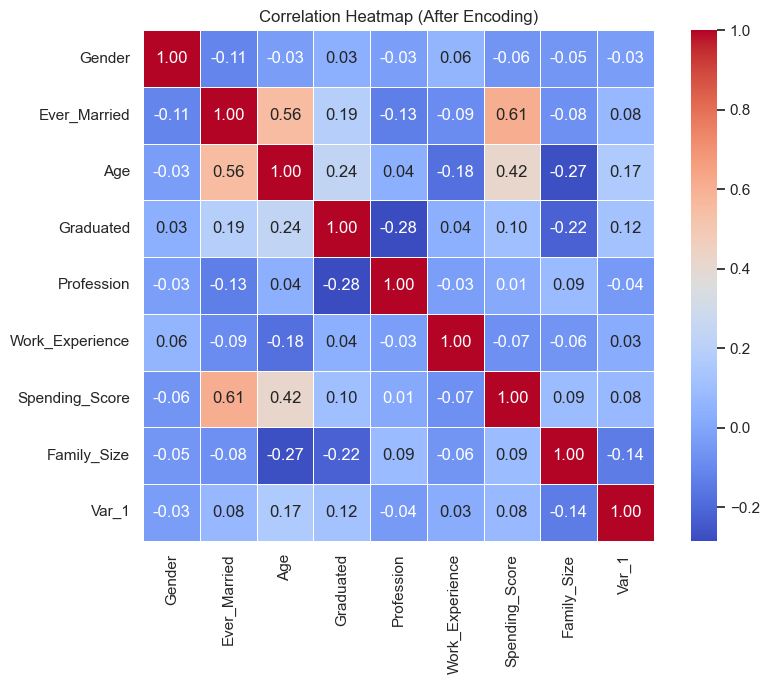

In [41]:
# Correlation heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap (After Encoding)')
plt.tight_layout()
plt.savefig('data/eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# Save everything for algorithm notebooks
pickle.dump(df_scaled,                    open('data/df_scaled.pkl',       'wb'))
pickle.dump(df_clean,                     open('data/df_clean.pkl',        'wb'))
pickle.dump(scaler,                       open('data/scaler.pkl',          'wb'))
pickle.dump(list(df_clean.columns),       open('data/feature_names.pkl',   'wb'))
pickle.dump(df['Segmentation'].values,    open('data/original_labels.pkl', 'wb'))

print('✅ Saved: df_scaled.pkl, df_clean.pkl, scaler.pkl, feature_names.pkl, original_labels.pkl')
print('\n🎉 Preprocessing complete! Now run notebooks 02, 03, 04.')

✅ Saved: df_scaled.pkl, df_clean.pkl, scaler.pkl, feature_names.pkl, original_labels.pkl

🎉 Preprocessing complete! Now run notebooks 02, 03, 04.
